# Cohort Conversion Analysis: Is **paid_social**'s Problem Volume or Quality?

The previous notebook found one dominant root cause behind the February revenue drop: the **paid_social** acquisition channel lost about two-thirds of its order volume, and everything that looked like an AOV/tariff-mix shift was a downstream side effect of that.

That leaves an open question with two very different implications for the business:

- Volume story: fewer people *registered* through **paid_social** in February (points to marketing spend, campaign pause, ad platform issue, or an attribution/tracking change).
- Quality story: the *same* number of people registered, but converted to a paid order less often (points to a product, onboarding, or traffic-quality problem).

### Methodology

We define 14-day conversion as: did a user place at least one paid order within 14 days of registering? Users registered after 2026-02-15 are excluded, because the raw order data only runs through 2026-02-28 - a user registered on the 15th is the last one whose full 14-day window (day 0 through day 13) is actually observable in the data. Including later cohorts would understate their conversion simply because we haven't watched them long enough yet.

All queries are defined in [**sql/04_cohort_conversion.sql**](../sql/04_cohort_conversion.sql).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.db import get_connection, load_query  # noqa: E402

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
PAID_SOCIAL_COLOR = "#d62728"
OTHER_COLOR = "#4c72b0"

SQL_FILE = "04_cohort_conversion.sql"
con = get_connection()

## 1. Overall weekly cohort conversion

First, the big picture: how does 14-day conversion move week over week, ignoring channel?

,cohort_week,cohort_users,users_with_paid_order_14d,conversion_14d_pct
0,2025-12-29,1687,98.0,5.81
1,2026-01-05,2942,238.0,8.09
2,2026-01-12,2849,298.0,10.46
3,2026-01-19,2968,360.0,12.13
4,2026-01-26,3025,361.0,11.93
5,2026-02-02,3514,255.0,7.26
6,2026-02-09,3476,326.0,9.38


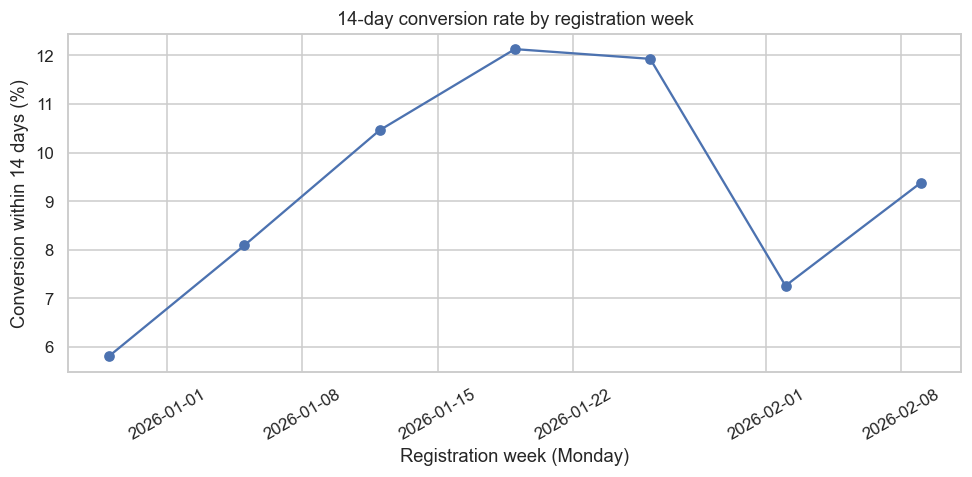

In [5]:
weekly = con.execute(load_query(SQL_FILE, "weekly_cohort_conversion")).fetchdf()
display(weekly)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(weekly["cohort_week"], weekly["conversion_14d_pct"], marker="o", color=OTHER_COLOR)
ax.set_title("14-day conversion rate by registration week")
ax.set_ylabel("Conversion within 14 days (%)")
ax.set_xlabel("Registration week (Monday)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

There's a clear saw-tooth pattern: conversion climbs from ~6% to ~12% across each month, then resets low at the start of the next month (this matches the within-month ramp-up we already saw in the daily revenue chart in notebook 00 - most likely an artifact of how the synthetic data was generated, not a real product effect). Because January had 5 cohort-weeks and February only had 3 (cut off by the 14-day observation window), a naive month-to-month average would be misleading. Comparing full calendar months directly (any user registered through 2026-02-15, one aggregate number per month) is more robust:

In [6]:
monthly_conv = con.execute(load_query(SQL_FILE, "monthly_conversion_comparison")).fetchdf()
display(monthly_conv)

,registration_month,cohort_users,users_with_paid_order_14d,conversion_14d_pct
0,2026-01-01,13000,1325.0,10.19
1,2026-02-01,7461,611.0,8.19


Overall conversion did fall, from 10.19% to 8.19% (-2.0 pp). That's a real, business-relevant number - but it's an average across 5 very different channels. Let's split it by **acquisition_channel** to see whether **paid_social** is dragging this down, or whether it's a broad-based decline.

## 2. Conversion by channel: is **paid_social**'s conversion rate the problem?

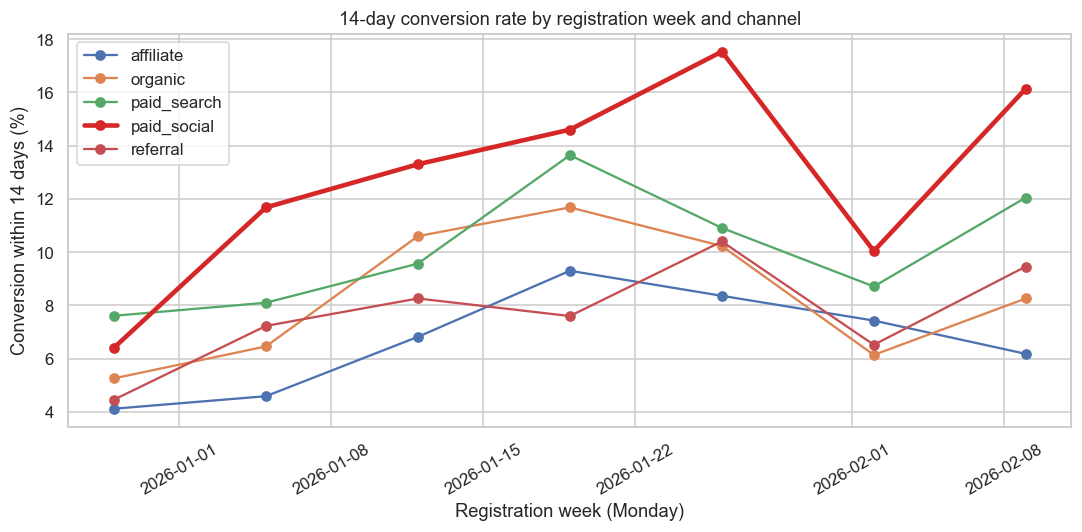

In [4]:
weekly_by_channel = con.execute(load_query(SQL_FILE, "weekly_cohort_conversion_by_channel")).fetchdf()

fig, ax = plt.subplots(figsize=(10, 5))
for channel, grp in weekly_by_channel.groupby("acquisition_channel"):
    color = PAID_SOCIAL_COLOR if channel == "paid_social" else None
    lw = 3 if channel == "paid_social" else 1.5
    ax.plot(grp["cohort_week"], grp["conversion_14d_pct"], marker="o", label=channel, color=color, linewidth=lw)
ax.set_title("14-day conversion rate by registration week and channel")
ax.set_ylabel("Conversion within 14 days (%)")
ax.set_xlabel("Registration week (Monday)")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**paid_social** (bold red) is noisy week to week - as expected once its own cohort sizes shrink in February - but it does not trend toward zero. If anything it stays among the higher-converting lines throughout. Let's confirm with the cleaner monthly aggregate.

,registration_month,acquisition_channel,cohort_users,users_with_paid_order_14d,conversion_14d_pct
0,2026-01-01,affiliate,1300,91.0,7.00
1,2026-02-01,affiliate,1453,98.0,6.74
2,2026-01-01,organic,4200,394.0,9.38
3,2026-02-01,organic,2932,206.0,7.03
4,2026-01-01,paid_search,2600,265.0,10.19
5,2026-02-01,paid_search,1574,163.0,10.36
6,2026-01-01,paid_social,3400,457.0,13.44
7,2026-02-01,paid_social,537,67.0,12.48
8,2026-01-01,referral,1500,118.0,7.87
9,2026-02-01,referral,965,77.0,7.98


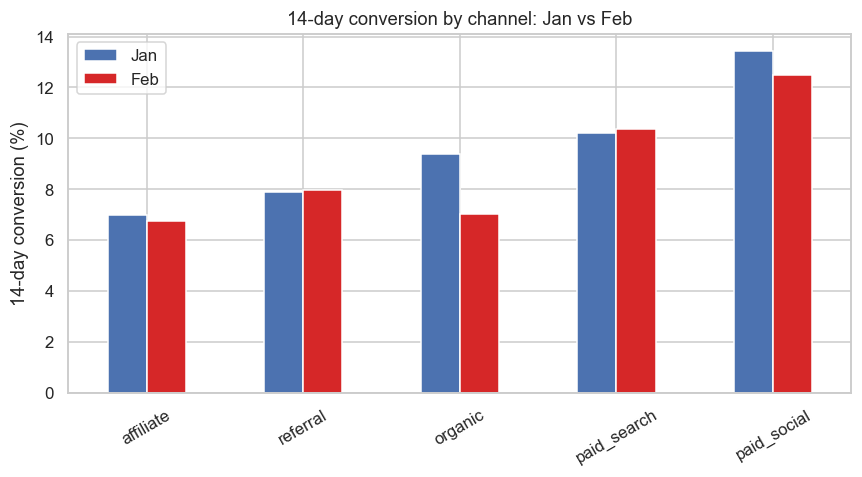

In [7]:
monthly_by_channel = con.execute(load_query(SQL_FILE, "monthly_conversion_by_channel")).fetchdf()
display(monthly_by_channel)

fig, ax = plt.subplots(figsize=(8, 4.5))
pivot = monthly_by_channel.pivot(index="acquisition_channel", columns="registration_month", values="conversion_14d_pct")
pivot.columns = ["Jan", "Feb"]
pivot = pivot.sort_values("Jan")
pivot.plot(kind="bar", ax=ax, color=[OTHER_COLOR, PAID_SOCIAL_COLOR])
ax.set_ylabel("14-day conversion (%)")
ax.set_title("14-day conversion by channel: Jan vs Feb")
ax.set_xlabel("")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**paid_social**'s conversion rate barely moved (13.44% -> 12.48%, -1.0 pp) - a small dip, still the 2nd-highest converting channel in February, and well within the noise visible in the weekly chart above. **organic** actually shows a bigger conversion drop (9.38% -> 7.03%) but that's a separate, smaller story.

## 3. The other half of the funnel: registration volume by channel

,Jan,Feb,change_pct
acquisition_channel,,,
paid_social,3400,1050,-69.1
paid_search,2600,2950,13.5
referral,1500,1750,16.7
organic,4200,5400,28.6
affiliate,1300,2750,111.5


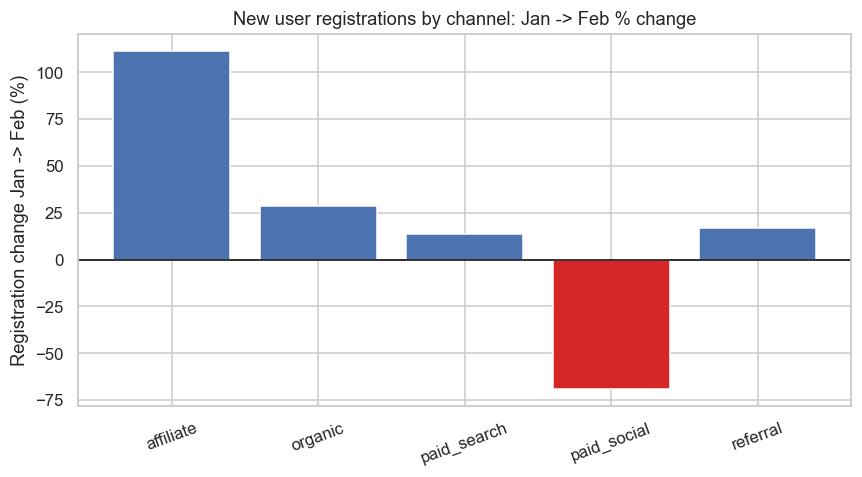

In [8]:
registrations = con.execute(load_query(SQL_FILE, "monthly_registrations_by_channel")).fetchdf()
reg_pivot = registrations.pivot(index="acquisition_channel", columns="registration_month", values="registrations")
reg_pivot.columns = ["Jan", "Feb"]
reg_pivot["change_pct"] = ((reg_pivot["Feb"] - reg_pivot["Jan"]) / reg_pivot["Jan"] * 100).round(1)
display(reg_pivot.sort_values("change_pct"))

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = [PAID_SOCIAL_COLOR if ch == "paid_social" else OTHER_COLOR for ch in reg_pivot.index]
ax.bar(reg_pivot.index, reg_pivot["change_pct"], color=colors)
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Registration change Jan -> Feb (%)")
ax.set_title("New user registrations by channel: Jan -> Feb % change")
plt.xticks(rotation=20)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "02_registrations_by_channel.png", dpi=150, bbox_inches="tight")
plt.show()

There it is: every other channel *grew* its registrations in February (+13% to +111%), while **paid_social** registrations collapsed from 3,400 to 1,050 (-69.1%).

## Conclusion

This is a top-of-funnel / acquisition-volume problem, not a conversion-quality problem. Once someone registers through **paid_social**, they are about as likely as before to place a paid order within 14 days (conversion basically flat, still one of the best-converting channels). The business simply stopped getting as many new **paid_social** registrations in February.

Combined with notebook 01, this fully explains the February revenue drop through a single chain of cause and effect:

**paid_social** acquisition volume fell ~69%
→ far fewer **paid_social** orders (which are historically large and premium-skewed)
→ blended AOV and "expensive tariff share" mechanically drop across the whole business
→ total revenue falls -13.5%, even though every other channel individually grew.

Typical real-world causes worth investigating with the marketing team: a paused or reduced ad budget, a change in the ad platform's algorithm or audience targeting, a broken tracking/attribution pixel undercounting **paid_social** sign-ups, or a seasonal dip in social ad performance. This dataset can't distinguish between those - that requires marketing spend and campaign data that isn't part of this export.

Next: [**03_conclusions_and_recommendations.ipynb**](03_conclusions_and_recommendations.ipynb) ties everything together into an executive summary.